In [1]:
import gc
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# Comment Category Prediction using Machine Learning

## Objective

The objective of this project is to build a robust machine learning pipeline to classify user comments into predefined categories.

This problem involves:
- **Unstructured data** → comment text
- **Structured data** → numerical and categorical features

To effectively solve this, we combine:
- Text vectorization (TF-IDF)
- Feature engineering
- Multiple machine learning models
- Ensemble learning (stacking)

The primary evaluation metric used is **Macro F1-score**, as the dataset may contain class imbalance and we want balanced performance across all classes.

In [2]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
train.head()

Train shape: (198000, 15)
Test shape:  (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [4]:
print("Shape:", train.shape)

Shape: (198000, 15)


In [5]:
print("Null Values:")
train.isnull().sum()

Null Values:


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [6]:
print("Null Percentage:")
(train.isnull().sum() / len(train) * 100).round(2)

Null Percentage:


created_date     0.00
post_id          0.00
emoticon_1       0.00
emoticon_2       0.00
emoticon_3       0.00
upvote           0.00
downvote         0.00
if_1             0.00
if_2             0.00
race            73.45
religion        73.45
gender          73.45
disability       0.00
comment          0.00
label            0.00
dtype: float64

In [7]:
print("Class Distribution:")
train['label'].value_counts().sort_index()

Class Distribution:


label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

In [8]:
print("Class Percentage:")
(train['label'].value_counts().sort_index() / len(train) * 100).round(2)

Class Percentage:


label
0    57.66
1     8.04
2    31.54
3     2.76
Name: count, dtype: float64

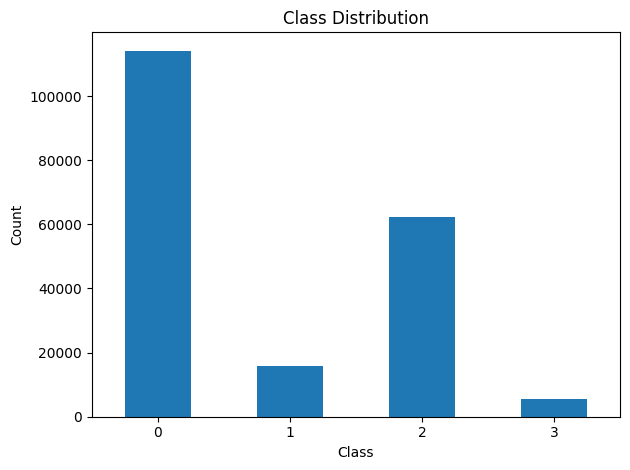

In [9]:
train['label'].value_counts().sort_index().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

In [10]:
num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

print("Basic Statistics:")
train[num_cols].describe()

Basic Statistics:


,upvote,downvote,emoticon_1,emoticon_2,emoticon_3,if_1,if_2
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,2.607975,0.666394,0.279768,0.048338,0.121071,1.906152,7.956212
std,5.054763,2.044335,1.023234,0.258477,0.481013,25.635752,14.839464
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,3.000000,1.000000,0.000000,0.000000,0.000000,4.000000,10.000000
max,201.000000,107.000000,47.000000,11.000000,17.000000,1860.000000,1833.000000


In [11]:
print("Mean per Class:")
train.groupby('label')[num_cols].mean().round(2)

Mean per Class:


,upvote,downvote,emoticon_1,emoticon_2,emoticon_3,if_1,if_2
label,,,,,,,
0,2.40,0.58,0.28,0.04,0.11,1.30,4.86
1,2.85,0.80,0.26,0.06,0.15,8.01,11.87
2,2.97,0.81,0.28,0.05,0.14,1.53,12.21
3,2.04,0.51,0.28,0.07,0.13,1.13,12.62


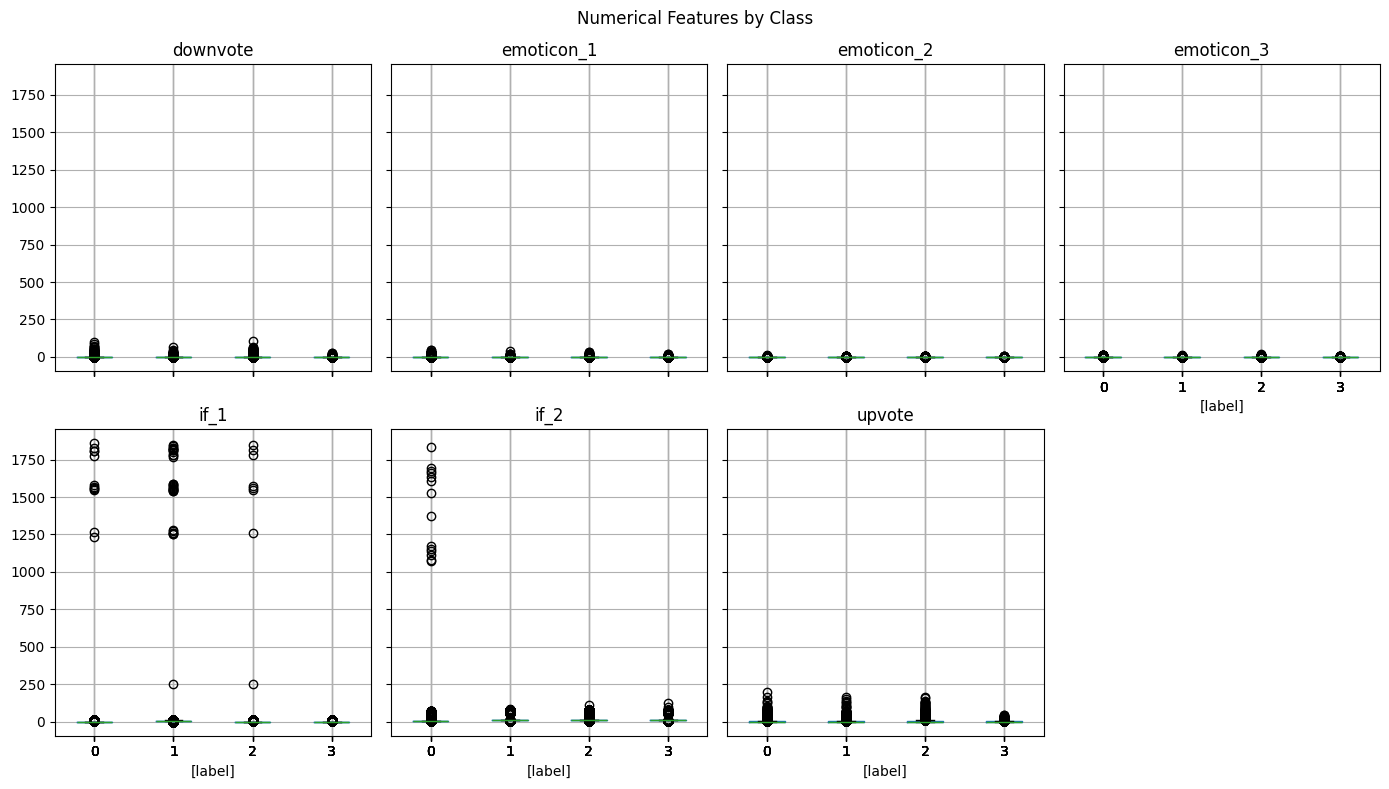

In [12]:
# Distribution of each numerical feature by class
train[num_cols + ['label']].boxplot(by='label', figsize=(14, 8), layout=(2, 4))
plt.suptitle('Numerical Features by Class')
plt.tight_layout()
plt.show()
plt.close()


race value counts:
race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64


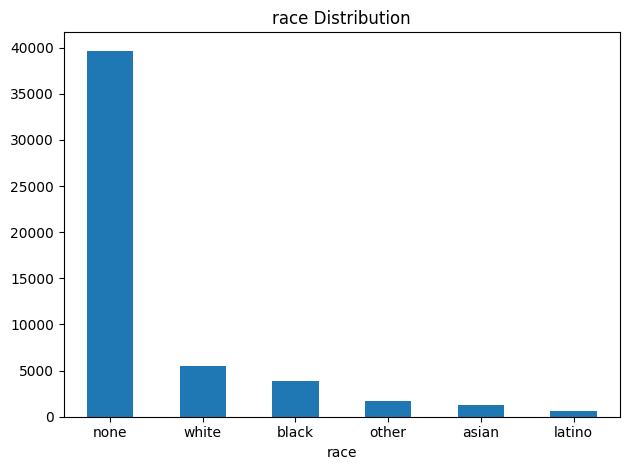


race vs label:
label       0     1      2    3
race                           
asian     570   364    305   24
black     608  2679    555   27
latino    274   200    143    6
none    20606  6138  11973  965
other     676   489    453   36
white     923  3338   1165   60

gender value counts:
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64


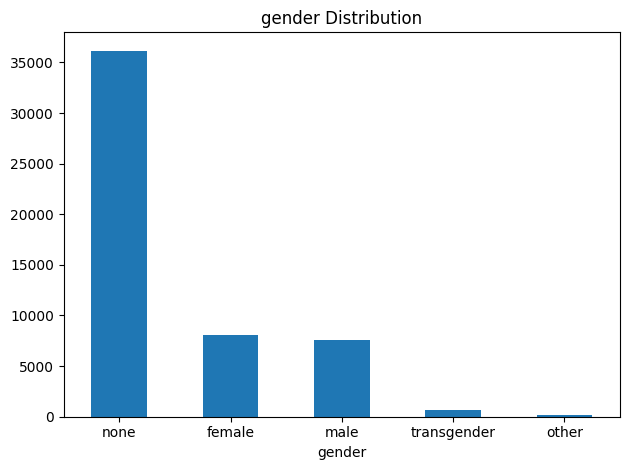


gender vs label:
label            0     1     2    3
gender                             
female        3449  1965  2425  198
male          2758  2142  2475  174
none         17201  8694  9529  737
other           75    79    50    4
transgender    174   328   115    5

religion value counts:
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64


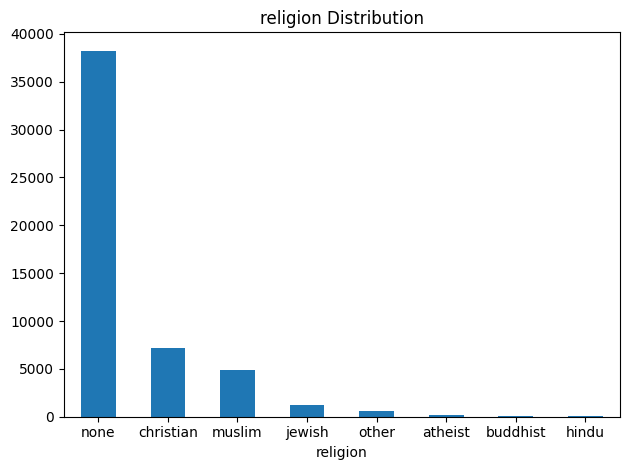


religion vs label:
label          0     1      2    3
religion                          
atheist       85    71     57    6
buddhist      43    39     17    1
christian   3460  2160   1498   73
hindu         50    29     17    1
jewish       348   673    210   13
muslim       965  3134    732   99
none       18524  6883  11928  914
other        182   219    135   11


In [13]:
cat_cols = ['race', 'gender', 'religion']

for col in cat_cols:
    print(f"\n{col} value counts:")
    print(train[col].value_counts())
    
    train[col].value_counts().plot(kind='bar', title=f'{col} Distribution')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"\n{col} vs label:")
    print(pd.crosstab(train[col], train['label']))

In [14]:
word_len = train['comment'].fillna('').apply(lambda x: len(str(x).split()))
char_len = train['comment'].fillna('').apply(len)

In [15]:
print("Word Length Statistics:")
word_len.describe()

Word Length Statistics:


count    198000.000000
mean         52.396985
std          45.770221
min           0.000000
25%          18.000000
50%          37.000000
75%          73.000000
max         315.000000
Name: comment, dtype: float64

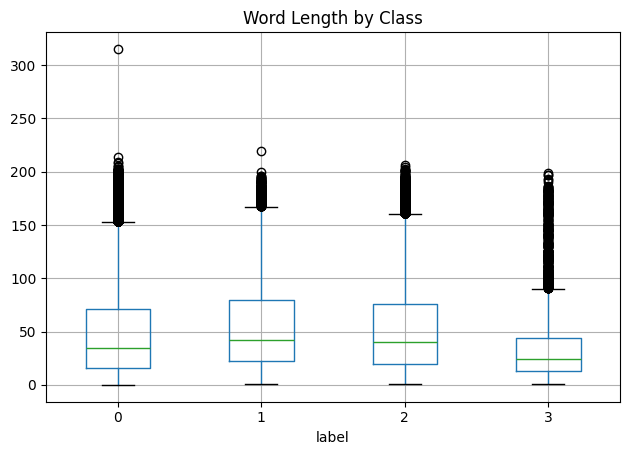

In [16]:
pd.DataFrame({'word_len': word_len, 'label': train['label']}).boxplot(column='word_len', by='label')
plt.title('Word Length by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()
plt.close()

In [17]:
print("Char Length Statistics:")
char_len.describe()

Char Length Statistics:


count    198000.000000
mean        302.909364
std         266.441749
min           0.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment, dtype: float64

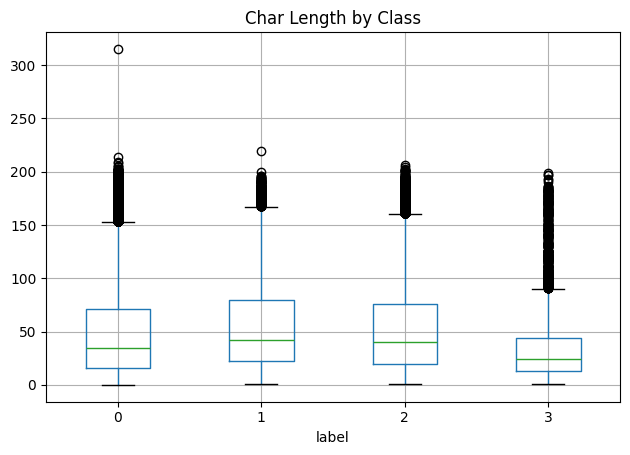

In [18]:
pd.DataFrame({'char_len': word_len, 'label': train['label']}).boxplot(column='char_len', by='label')
plt.title('Char Length by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()
plt.close()

In [19]:
print("Average Text Length per Class:")
pd.DataFrame({'word_len': word_len, 'char_len': char_len, 'label': train['label']}).groupby('label')[['word_len', 'char_len']].mean().round(2)

Average Text Length per Class:


,word_len,char_len
label,,
0,51.19,295.90
1,57.23,335.71
2,54.90,316.89
3,34.98,194.17


In [20]:
del word_len, char_len
gc.collect()

12863

upvote: 17304 outliers (8.74%)
downvote: 15173 outliers (7.66%)
emoticon_1: 28922 outliers (14.61%)
emoticon_2: 8109 outliers (4.10%)
emoticon_3: 17165 outliers (8.67%)
if_1: 85 outliers (0.04%)
if_2: 3930 outliers (1.98%)


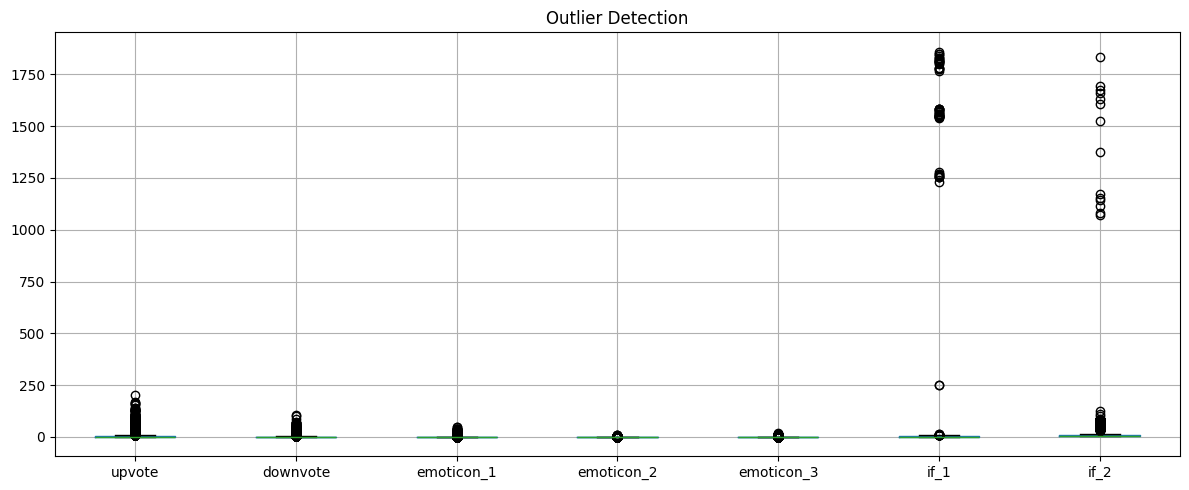

In [21]:
for col in num_cols:
    Q1  = train[col].quantile(0.25)
    Q3  = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train[(train[col] < Q1 - 1.5 * IQR) | (train[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train)*100:.2f}%)")

del outliers
gc.collect()

train[num_cols].boxplot(figsize=(12, 5))
plt.title('Outlier Detection')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

In [22]:
num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 
            'emoticon_3', 'if_1', 'if_2', 'label']

train[num_cols].corr()

,upvote,downvote,emoticon_1,emoticon_2,emoticon_3,if_1,if_2,label
upvote,1.000000,0.314557,0.128124,0.081580,0.170662,-0.001654,-0.000674,0.040181
downvote,0.314557,1.000000,0.177236,0.169366,0.371039,0.000354,0.006307,0.044908
emoticon_1,0.128124,0.177236,1.000000,0.092087,0.144864,-0.002624,-0.004116,-0.003218
emoticon_2,0.081580,0.169366,0.092087,1.000000,0.140236,0.001741,0.003919,0.021597
emoticon_3,0.170662,0.371039,0.144864,0.140236,1.000000,-0.000514,0.007191,0.027273
if_1,-0.001654,0.000354,-0.002624,0.001741,-0.000514,1.000000,0.008174,0.007543
if_2,-0.000674,0.006307,-0.004116,0.003919,0.007191,0.008174,1.000000,0.232902
label,0.040181,0.044908,-0.003218,0.021597,0.027273,0.007543,0.232902,1.000000


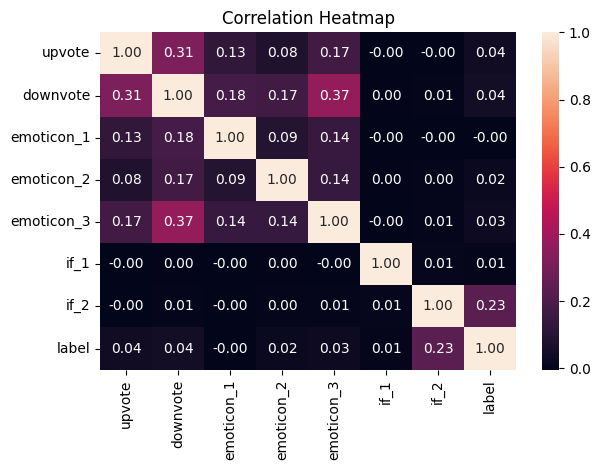

In [23]:
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.close()

## Exploratory Data Analysis (EDA) & Insights

### Dataset Overview
The dataset consists of:
- A text column: `comment`
- Numerical features: upvotes, downvotes, emoticons, flags
- Categorical features: race, gender, religion
- Target variable: `label`

### Key Observations

1. **Class Distribution**
   - The dataset shows some level of imbalance across classes.
   - This justifies the use of **Macro F1-score** instead of accuracy.

2. **Text Characteristics**
   - Comments vary significantly in length.
   - Some classes tend to have longer or shorter comments on average.

3. **Numerical Features**
   - Features like upvotes, downvotes, and emoticons vary across classes.
   - These can provide useful signals about comment type.

4. **Categorical Features**
   - Distribution of race, gender, and religion differs across labels.
   - These features may help improve classification performance.

5. **Outliers**
   - Some numerical features contain outliers.
   - However, tree-based models like XGBoost are robust to outliers.

6. **Correlation**
   - No strong linear correlation between features and label.
   - Indicates need for non-linear models and feature interactions.

These insights guided the feature engineering and model selection process.

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9!?.,\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

In [25]:
def handling_features(df):
    df = df.copy()

    df['race'] = df['race'].fillna('missing')
    df['gender'] = df['gender'].fillna('missing')
    df['religion'] = df['religion'].fillna('missing')
    df['comment'] = df['comment'].fillna('')

    df['comment']     = df['comment'].apply(clean_text)

    df['disability'] = df['disability'].astype(int)
    
    df['hour'] = pd.to_datetime(df['created_date'], format='%Y-%m-%d %H:%M:%S.%f%z', utc=True).dt.hour
    df = df.drop(columns=['created_date'])
    df = df.drop(columns=['post_id'])
    
    df['word_len'] = df['comment'].fillna('').apply(lambda x: len(str(x).split()))
    df['char_len'] = df['comment'].fillna('').apply(len)
    df['upvote_ratio'] = df['upvote'] / (df['upvote'] + df['downvote'] + 1e-6)
    df['emotion_total'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['if2_emo_int'] = df['if_2'] * df['emotion_total']
    df['if2_upvote_rat_int'] = df['if_2'] * df['upvote_ratio']
    
    return df

train = handling_features(train)
test  = handling_features(test)

## Feature Engineering

To enhance model performance, several new features were created:

### 1. Text Preprocessing
Before extracting text features, all comments were cleaned using a custom function:
- Converted to **lowercase**
- **URLs** removed (`http://...`, `www...`)
- **Special characters** removed — only letters, digits, and basic punctuation (`! ? . ,`) retained
- **Extra whitespace** normalized

This ensures the TF-IDF vectorizer works on clean, consistent text rather than noisy raw input.

### 2. Text-based Features
- **Word Length**: Number of words in the comment
- **Character Length**: Total characters in the comment

These capture verbosity and writing style.

### 3. Engagement Features
- **Upvote Ratio**:

$$\text{upvote ratio} = \frac{\text{upvotes}}{\text{upvotes} + \text{downvotes}}$$

This reflects how positively a comment is received.

- **Total Emotions**: Sum of all emoticon counts.

### 4. Interaction Features
Interaction between features helps capture non-linear relationships:
- `if_2 × emotion_total`
- `if_2 × upvote_ratio`

### 5. Time-based Feature
- Extracted **hour** from timestamp.
- Helps capture temporal patterns in comment behavior.

### 6. Data Cleaning
- Missing categorical values → replaced with `"missing"`
- Missing text → replaced with empty string

These engineered features allow models to learn more complex patterns beyond raw inputs.

In [26]:
Y = train['label']
X = train.drop(columns=['label'])

cat_cols =  ['race', 'gender', 'religion']
num_cols = X.select_dtypes(include=np.number).columns.tolist()

del train
gc.collect()

15045

In [27]:
from sklearn.preprocessing import PowerTransformer

num_pipeline = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson')),
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


In [28]:
lr_pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1,class_weight='balanced'))
])

sgd_pipeline = Pipeline([
    ('clf', SGDClassifier(loss='hinge', max_iter=1000, random_state=42, n_jobs=-1))
])

svm_pipeline = Pipeline([
    ('clf', LinearSVC(max_iter=2000, random_state=42))
])

xgb = XGBClassifier(
    device='cuda',
    tree_method='hist',
    random_state=42,
    max_bin=64,         
    subsample=0.8,       
    colsample_bytree=0.5,
    n_estimators=700,    
    max_depth=5
)

## Data Preprocessing

We used a structured preprocessing pipeline:

### Numerical Features
- Transformed using **PowerTransformer (Yeo-Johnson)**  
- Helps normalize skewed distributions

### Categorical Features
- Encoded using **OneHotEncoder**
- Handles unseen categories with `handle_unknown='ignore'`

### Text Features
- **Word-level TF-IDF**
  - N-grams: (1,2)
  - Captures word sequences

- **Character-level TF-IDF**
  - N-grams: (3,5)
  - Captures spelling/style patterns

### Final Feature Matrix
All features are combined using:
- Sparse matrix stacking (`hstack`)

This ensures efficient handling of high-dimensional data.

## Modeling Strategy

We experimented with multiple models:

### 1. Logistic Regression
- Works well for high-dimensional sparse data
- Used with class balancing

### 2. SGD Classifier
- Fast and scalable
- Useful baseline for linear models

### 3. Support Vector Machine (LinearSVC)
- Effective for text classification
- Handles large feature spaces well

### 4. XGBoost
- Tree-based model
- Captures non-linear relationships
- GPU acceleration used for faster training

### Validation Strategy
- **Stratified K-Fold Cross Validation (k=3)**
- Ensures each fold has balanced class distribution
- Prevents overfitting and gives reliable performance estimates

In [29]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_scores  = []
sgd_scores  = []
svm_scores = []
xgb_scores = []

last_fold_preds = {}

for train_index, validation_index in cv.split(X, Y):
    
    X_train_original, X_validation_original = X.iloc[train_index], X.iloc[validation_index]
    
    # preprocess
    X_train_processed = preprocessor.fit_transform(X_train_original)
    X_validation_processed = preprocessor.transform (X_validation_original)

    tfidf_word = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=20000, min_df=5, sublinear_tf=True)
    tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=15000, min_df=5, sublinear_tf=True)

    # TFIDF
    tfidf_word_train = tfidf_word.fit_transform(X_train_original['comment'])
    tfidf_word_validation = tfidf_word.transform (X_validation_original['comment'])

    tfidf_char_train = tfidf_char.fit_transform(X_train_original['comment'])
    tfidf_char_validation = tfidf_char.transform (X_validation_original['comment'])

    X_train = hstack([X_train_processed, tfidf_word_train, tfidf_char_train])
    X_validation = hstack([X_validation_processed, tfidf_word_validation, tfidf_char_validation])

    y_train      = Y.iloc[train_index]
    y_validation = Y.iloc[validation_index]

    del X_train_processed, X_validation_processed
    del tfidf_word_train, tfidf_word_validation
    del tfidf_char_train, tfidf_char_validation
    gc.collect()

    # LR
    lr_pipeline.fit(X_train, y_train)
    lr_pred = lr_pipeline.predict(X_validation)
    lr_scores.append(f1_score(y_validation, lr_pred, average='macro'))

    # SGD
    sgd_pipeline.fit(X_train,y_train)
    sgd_pred = sgd_pipeline.predict(X_validation)
    sgd_scores.append(f1_score(y_validation, sgd_pred, average='macro'))

    # SVM
    svm_pipeline.fit(X_train,y_train)
    svm_pred = svm_pipeline.predict(X_validation)
    svm_scores.append(f1_score(y_validation, svm_pred, average='macro'))

    # XGB
    xgb.fit(X_train,y_train)
    xgb_pred = xgb.predict(X_validation)
    xgb_scores.append(f1_score(y_validation, xgb_pred, average='macro'))

    last_fold_preds = {
    'y_true': Y.iloc[validation_index],
    'lr':     lr_pred,
    'sgd':    sgd_pred,
    'svm':    svm_pred,
    'xgb':    xgb_pred,
    }

    del X_train, X_validation, y_train, y_validation
    del lr_pred, sgd_pred, svm_pred, xgb_pred
    gc.collect()

print("Model Comparison:")
print(f"LR  F1:  {np.mean(lr_scores):.4f}")
print(f"SGD F1:  {np.mean(sgd_scores):.4f}")
print(f"SVM F1:  {np.mean(svm_scores):.4f}")
print(f"XGB F1:  {np.mean(xgb_scores):.4f}")

Model Comparison:
LR  F1:  0.7973
SGD F1:  0.7514
SVM F1:  0.7939
XGB F1:  0.8076


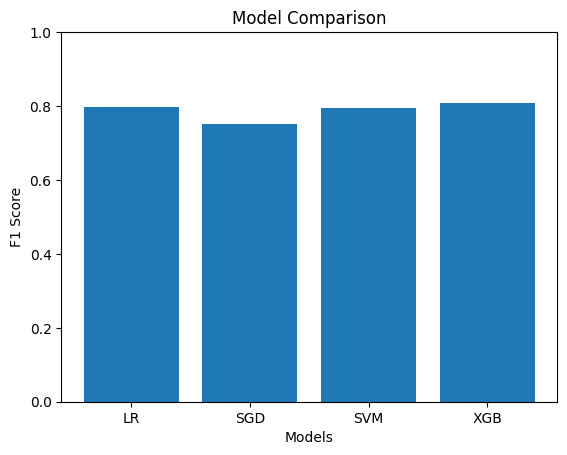

2620

In [30]:
models = ['LR', 'SGD', 'SVM', 'XGB']
scores = [
    np.mean(lr_scores),
    np.mean(sgd_scores),
    np.mean(svm_scores),
    np.mean(xgb_scores)
]

plt.figure()
plt.bar(models, scores)
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()
plt.close()

del scores
gc.collect()

## Model Evaluation & Comparison

### Evaluation Metric
- **Macro F1-score**
  - Treats all classes equally
  - Suitable for imbalanced datasets

### Results Summary
- Logistic Regression: Stable and interpretable
- SGD: Fast but slightly lower performance
- SVM: Strong performance on text features
- XGBoost: Best at capturing complex patterns

### Observations
- Linear models perform well due to TF-IDF features
- XGBoost adds value by modeling non-linear interactions
- No single model dominates → motivates ensemble approach

## Detailed Evaluation

To better understand performance:

- **Classification Report**
  - Precision: accuracy of predictions
  - Recall: ability to find all instances
  - F1-score: balance of precision & recall

- **Confusion Matrix**
  - Shows misclassification patterns
  - Helps identify which classes are confused

These metrics provide deeper insights beyond overall score.

In [31]:
y_true = last_fold_preds['y_true']
 
for name, preds in [('LR', last_fold_preds['lr']),
                    ('SGD', last_fold_preds['sgd']),
                    ('SVM', last_fold_preds['svm']),
                    ('XGB', last_fold_preds['xgb'])]:

    print(f"  {name} — Classification Report (last fold)")
    print(classification_report(y_true, preds))

  LR — Classification Report (last fold)
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     38058
           1       0.70      0.85      0.77      5306
           2       0.87      0.87      0.87     20813
           3       0.50      0.77      0.60      1823

    accuracy                           0.90     66000
   macro avg       0.76      0.85      0.80     66000
weighted avg       0.91      0.90      0.90     66000

  SGD — Classification Report (last fold)
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     38058
           1       0.81      0.72      0.76      5306
           2       0.81      0.91      0.86     20813
           3       0.85      0.29      0.44      1823

    accuracy                           0.90     66000
   macro avg       0.86      0.72      0.75     66000
weighted avg       0.90      0.90      0.89     66000

  SVM — Classification Report (last fold)
     

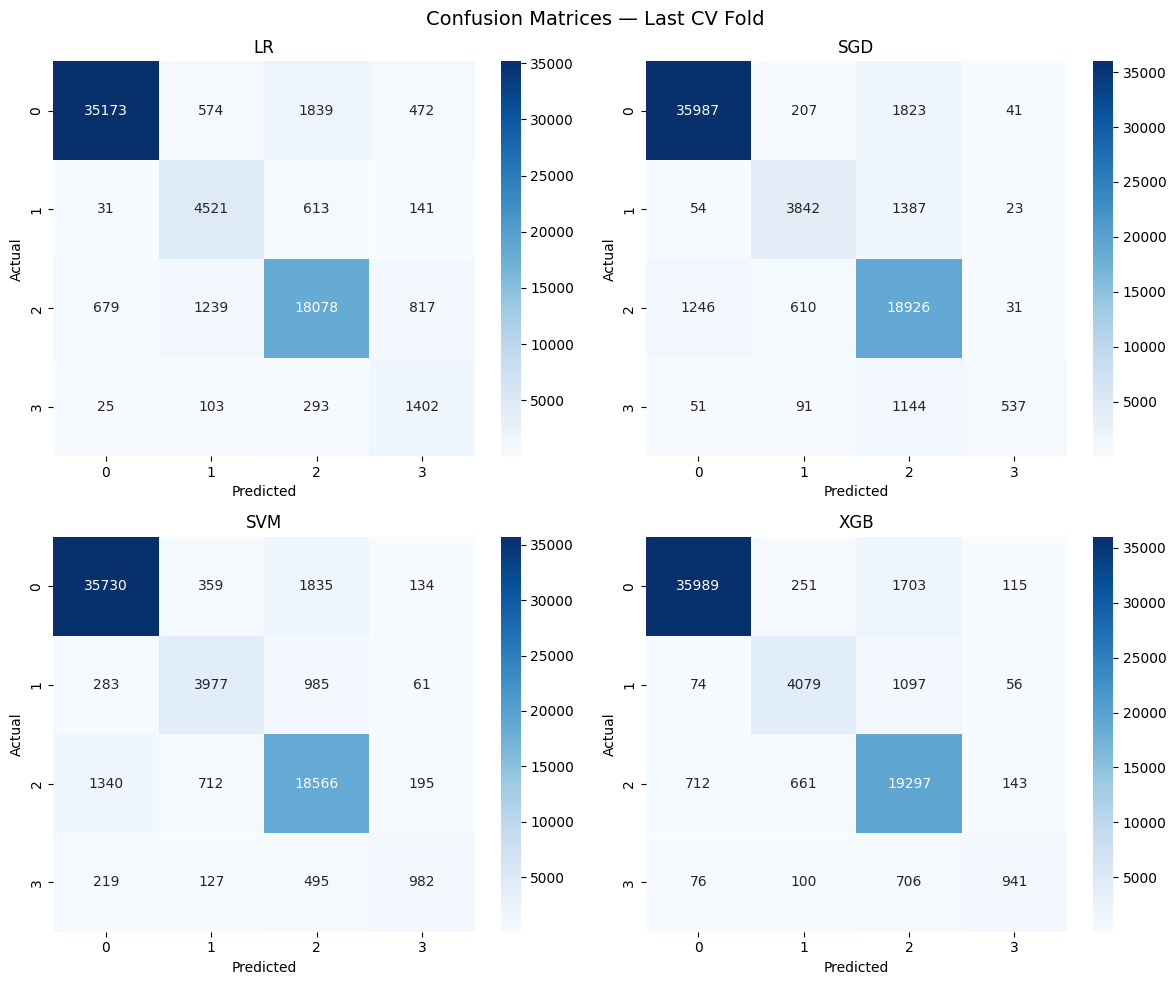

15

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — Last CV Fold', fontsize=14)
 
for ax, (name, preds) in zip(axes.flat, [('LR',  last_fold_preds['lr']),
                                          ('SGD', last_fold_preds['sgd']),
                                          ('SVM', last_fold_preds['svm']),
                                          ('XGB', last_fold_preds['xgb'])]):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
 
plt.tight_layout()
plt.show()
plt.close()

del last_fold_preds, y_true, cm
gc.collect()

In [33]:
train_processed = preprocessor.fit_transform(X)

tfidf_word = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=20000, min_df=5, sublinear_tf=True)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=15000, min_df=5, sublinear_tf=True)

In [34]:
tw = tfidf_word.fit_transform(X['comment'])
tc = tfidf_char.fit_transform(X['comment'])

X_final = hstack([csr_matrix(train_processed), tw, tc])

del train_processed, tw, tc
gc.collect()

0

## Hyperparameter Tuning

We used **RandomizedSearchCV** to optimize model parameters:

### Logistic Regression
- Regularization strength (C)
- Solver type

### SVM
- Regularization parameter (C)
- Loss function

### XGBoost
- Number of trees
- Tree depth
- Learning rate
- Subsampling parameters

Tuning helps improve generalization and model performance.

In [35]:
param_dist = {
    'clf__C':      [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['lbfgs', 'liblinear']
}

lr_tuned = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lr_tuned.fit(X_final, Y)

print("Best params:", lr_tuned.best_params_)
print("Best F1:   ", lr_tuned.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  

Best params: {'clf__solver': 'liblinear', 'clf__C': 1}
Best F1:    0.8154788726063643


In [36]:
svm_param_dist = {
    'clf__C':    [0.01, 0.1, 1, 10, 100],
    'clf__loss': ['hinge', 'squared_hinge'],
}
 
svm_tuned = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
 
svm_tuned.fit(X_final, Y)
 
print("SVM Best params:", svm_tuned.best_params_)
print("SVM Best F1:    ", svm_tuned.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM Best params: {'clf__loss': 'squared_hinge', 'clf__C': 1}
SVM Best F1:     0.7947541965880585


In [37]:
xgb_param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5],
    'learning_rate':    [0.01, 0.05, 0.1, 0.3],
    'subsample':        [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
}
 
xgb_tuned = RandomizedSearchCV(
    XGBClassifier(device='cuda', tree_method='hist', random_state=42, max_bin=64),
    param_distributions=xgb_param_dist,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)
 
xgb_tuned.fit(X_final, Y)
 
print("XGB Best params:", xgb_tuned.best_params_)
print("XGB Best F1:    ", xgb_tuned.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
XGB Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGB Best F1:     0.31568724642765916


In [38]:
del lr_tuned, svm_tuned, xgb_tuned
gc.collect()

299

## Final Model: Stacking Ensemble

To leverage strengths of different models, we used **stacking**:

### Base Models
- Logistic Regression
- SVM
- XGBoost

### Final Estimator
- XGBoost

### Why Stacking?
- Combines predictions from multiple models
- Reduces individual model weaknesses
- Improves overall performance

This approach captures both:
- Linear relationships (LR, SVM)
- Non-linear patterns (XGBoost)

In [39]:
stack = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42,n_jobs=-1)),
        ('xgb', XGBClassifier(
            device='cuda',
            tree_method='hist',
            random_state=42,
            max_bin=64,          
            subsample=0.8,       
            colsample_bytree=0.5,
            n_estimators=700,    
            max_depth=5)),
        ('svm', LinearSVC(max_iter=2000,random_state=42))
    ],
    final_estimator=XGBClassifier(device='cuda', tree_method='hist'),
    cv=3,
    n_jobs=1
)

stack.fit(X_final, Y)

del X_final, Y
gc.collect()

301

In [40]:
test_processed = preprocessor.transform(test)

tw_test = tfidf_word.transform(test['comment'])
tc_test = tfidf_char.transform(test['comment'])

best_model = stack
test_final = hstack([test_processed, tw_test, tc_test])

del test_processed, tw_test, tc_test, test
gc.collect()

preds = best_model.predict(test_final)

del test_final
gc.collect()

38

## Final Prediction & Submission

- The final model is trained on the **entire dataset**
- Predictions are generated on the test set
- Output is formatted according to competition requirements

Submission file contains:
- `id`
- `predicted label`

This is uploaded to Kaggle for evaluation.

In [41]:
submission = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

submission['label'] = preds

submission.to_csv(
    'submission.csv',
    index=False
)

print("Submission saved.")

Submission saved.


## Conclusion

- Combining **text and structured data** significantly improves performance.
- TF-IDF is highly effective for text representation.
- Feature engineering adds meaningful signals to the model.
- Ensemble methods outperform individual models.

### Final Takeaway
A well-designed pipeline with:
- Proper preprocessing
- Strong feature engineering
- Multiple models
- Ensemble learning

leads to robust and high-performing solutions.

In [42]:
# import pandas as pd
# import numpy as np
# import re
# import gc
# from scipy.sparse import hstack, csr_matrix
# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import f1_score, classification_report
# from collections import Counter
# import lightgbm as lgb

# def clean_text(text):
#     text = str(text).lower()
#     text = re.sub(r"http\S+|www\S+", "", text)
#     text = re.sub(r"[^a-z0-9!?.,\s]", " ", text)
#     return re.sub(r"\s+", " ", text).strip()

# OUTLIER_COLS = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']

# def compute_iqr_caps(df, cols, multiplier=3.0):
#     caps = {}
#     for col in cols:
#         if col not in df.columns: continue
#         q1 = df[col].quantile(0.25)
#         q3 = df[col].quantile(0.75)
#         caps[col] = q3 + multiplier * (q3 - q1)
#     return caps

# def apply_iqr_caps(df, caps):
#     df = df.copy()
#     for col, cap in caps.items():
#         if col in df.columns:
#             df[col] = df[col].clip(upper=cap)
#     return df

# CAT_COLS = ['race', 'gender', 'religion', 'if_2_cat']

# def get_features(df_in, is_train=True):
#     df = df_in.copy()
    
#     orig_text_cats = ['race', 'gender', 'religion']
#     df[orig_text_cats] = df[orig_text_cats].fillna('missing_value').replace('none', 'missing_value')
    
#     df['if_2_cat'] = df['if_2'].fillna(-999).astype(str)

#     df['comment_raw']       = df['comment'].fillna('')
#     df['comment_clean']     = df['comment_raw'].apply(clean_text)
#     df['emo_sum']           = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
#     df['if2_emo_intensity'] = df['if_2'] * df['emo_sum']
#     df['cap_ratio']         = df['comment_raw'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
#     df['upvote_ratio']      = df['upvote'] / (df['upvote'] + df['downvote'] + 1e-6)
#     df['word_len']          = df['comment_clean'].str.split().apply(len).astype(np.int16)
#     df['char_len']          = df['comment_clean'].str.len().astype(np.int16)
    
#     exclusive_v = {'shoot','shooting','murder','penalty','burn','suicide','hang','weapon','bomb','knife'}
#     exclusive_p = {'lock','prison','cops','penalty','guilty'}
#     v_score = df['comment_clean'].apply(lambda x: len(set(x.split()) & exclusive_v))
#     p_score = df['comment_clean'].apply(lambda x: len(set(x.split()) & exclusive_p))
    
#     df['justice_density']    = (v_score + p_score) / (df['word_len'] + 1)
#     df['if2_violence_inter'] = df['if_2'] * v_score
#     df['is_blunt_justice']   = ((df['char_len'] < 200) & (v_score > 0)).astype(np.int8)
#     df['hour']               = pd.to_datetime(df['created_date'], format='%Y-%m-%d %H:%M:%S.%f%z', utc=True).dt.hour
#     df['disability']         = df['disability'].fillna(0).astype(np.int8)
    
#     drop_cols = ['comment','comment_raw','created_date','comment_clean','emo_sum']
#     return df.drop(columns=drop_cols), df['comment_clean']

# LOG1P_COLS = ['if_2','if_1','if2_emo_intensity','if2_violence_inter','justice_density',
#               'downvote','emoticon_1','cap_ratio','emoticon_2','upvote','emoticon_3','char_len','word_len']

# def apply_skew_transforms(df, is_train=True, clip_dict=None):
#     df = df.copy()
#     if is_train:
#         clip_dict = {}
#         for col in LOG1P_COLS:
#             if col not in df.columns: continue
#             pct = 99.0 if col == 'justice_density' else 99.9
#             clip_dict[col] = np.percentile(df[col].dropna(), pct)
#     for col in LOG1P_COLS:
#         if col not in df.columns: continue
#         df[col] = np.log1p(np.clip(df[col], 0, clip_dict[col]))
#     return df, clip_dict

# def f1_macro_lgb(y_true, y_pred):
#     y_pred = np.argmax(y_pred.reshape(-1, 4), axis=1)
#     return 'f1_macro', f1_score(y_true, y_pred, average='macro'), True

# def build_matrices(train_idx, val_idx, X_tab, clean_text_col,
#                    X_test_tab, test_clean_col, iqr_caps, fit_test=True):
#     train_text = clean_text_col.iloc[train_idx]
#     val_text   = clean_text_col.iloc[val_idx]
    
#     tfidf_w_lgb = TfidfVectorizer(analyzer='word',    ngram_range=(1,2), max_features=20000, min_df=5, sublinear_tf=True)
#     tfidf_c_lgb = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,4), max_features=15000, min_df=5, sublinear_tf=True)
#     tfidf_w_lr  = TfidfVectorizer(analyzer='word',    ngram_range=(1,2), max_features=50000, min_df=3, sublinear_tf=True)
#     tfidf_c_lr  = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=15000, min_df=3, sublinear_tf=True)
    
#     tw_lgb_tr = tfidf_w_lgb.fit_transform(train_text)
#     tc_lgb_tr = tfidf_c_lgb.fit_transform(train_text)
#     tw_lr_tr  = tfidf_w_lr.fit_transform(train_text)
#     tc_lr_tr  = tfidf_c_lr.fit_transform(train_text)
    
#     X_tab_tr = apply_iqr_caps(X_tab.iloc[train_idx].copy(), iqr_caps)
#     X_tab_vl = apply_iqr_caps(X_tab.iloc[val_idx].copy(),   iqr_caps)
    
#     X_tab_tr_num = X_tab_tr.drop(columns=CAT_COLS, errors='ignore')
#     X_tab_vl_num = X_tab_vl.drop(columns=CAT_COLS, errors='ignore')
    
#     ohe_lgb    = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
#     cat_tr_lgb = ohe_lgb.fit_transform(X_tab_tr[CAT_COLS])
#     cat_vl_lgb = ohe_lgb.transform(X_tab_vl[CAT_COLS])
    
#     X_tr_lgb = hstack([csr_matrix(X_tab_tr_num.values.astype(np.float32)), cat_tr_lgb, tw_lgb_tr, tc_lgb_tr]).astype(np.float32)
#     X_vl_lgb = hstack([csr_matrix(X_tab_vl_num.values.astype(np.float32)), cat_vl_lgb, tfidf_w_lgb.transform(val_text), tfidf_c_lgb.transform(val_text)]).astype(np.float32)
    
#     ohe_lr    = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
#     cat_tr_lr = ohe_lr.fit_transform(X_tab_tr[CAT_COLS])
#     cat_vl_lr = ohe_lr.transform(X_tab_vl[CAT_COLS])
    
#     X_tab_tr_sk, clip_dict = apply_skew_transforms(X_tab_tr_num, is_train=True)
#     X_tab_vl_sk, _         = apply_skew_transforms(X_tab_vl_num, is_train=False, clip_dict=clip_dict)
    
#     scaler    = StandardScaler(with_mean=False)
#     num_tr_sc = csr_matrix(scaler.fit_transform(X_tab_tr_sk.values.astype(np.float32)))
#     num_vl_sc = csr_matrix(scaler.transform(X_tab_vl_sk.values.astype(np.float32)))
    
#     X_tr_lr = hstack([num_tr_sc, cat_tr_lr, tw_lr_tr, tc_lr_tr])
#     X_vl_lr = hstack([num_vl_sc, cat_vl_lr, tfidf_w_lr.transform(val_text), tfidf_c_lr.transform(val_text)])
    
#     X_te_lgb = X_te_lr = None
#     if fit_test:
#         X_tab_te     = apply_iqr_caps(X_test_tab.copy(), iqr_caps)
#         X_tab_te_num = X_tab_te.drop(columns=CAT_COLS, errors='ignore')
#         cat_te_lgb   = ohe_lgb.transform(X_tab_te[CAT_COLS])
#         X_te_lgb = hstack([csr_matrix(X_tab_te_num.values.astype(np.float32)), cat_te_lgb, tfidf_w_lgb.transform(test_clean_col), tfidf_c_lgb.transform(test_clean_col)]).astype(np.float32)
        
#         X_tab_te_sk, _ = apply_skew_transforms(X_tab_te_num, is_train=False, clip_dict=clip_dict)
#         cat_te_lr      = ohe_lr.transform(X_tab_te[CAT_COLS])
#         num_te_sc      = csr_matrix(scaler.transform(X_tab_te_sk.values.astype(np.float32)))
#         X_te_lr = hstack([num_te_sc, cat_te_lr, tfidf_w_lr.transform(test_clean_col), tfidf_c_lr.transform(test_clean_col)])
        
#     del tw_lgb_tr, tc_lgb_tr, tw_lr_tr, tc_lr_tr
#     del X_tab_tr, X_tab_vl, X_tab_tr_num, X_tab_vl_num, X_tab_tr_sk, X_tab_vl_sk
#     del cat_tr_lgb, cat_vl_lgb, cat_tr_lr, cat_vl_lr
#     gc.collect()
    
#     return (X_tr_lgb, X_vl_lgb, X_tr_lr, X_vl_lr, X_te_lgb, X_te_lr, scaler, clip_dict)


# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# Y     = train['label']
# X_tab,      clean_text_col = get_features(train.drop(columns=['label','post_id']), is_train=True)
# X_test_tab, test_clean_col = get_features(test.drop(columns=['post_id']),            is_train=False)

# iqr_caps = compute_iqr_caps(X_tab, OUTLIER_COLS, multiplier=3.0)

# counts      = Counter(Y)
# n_total, n_classes = len(Y), 4
# lr_softened = {cls: round(
#     np.sqrt(n_total / (n_classes * cnt)) /
#     np.sqrt(n_total / (n_classes * counts[0])), 3)
#     for cls, cnt in counts.items()}
# print("\nLR weights:", lr_softened)

# N_SPLITS       = 5
# skf            = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
# lgb_oof        = np.zeros((len(Y), 4))
# lr_oof         = np.zeros((len(Y), 4))
# lgb_test_folds = []
# lr_test_folds  = []

# for fold, (t_idx, v_idx) in enumerate(skf.split(X_tab, Y)):
#     print(f"\n{'='*55}\nFOLD {fold+1}/{N_SPLITS}\n{'='*55}")
#     (X_tr_lgb, X_vl_lgb, X_tr_lr, X_vl_lr,
#      X_te_lgb, X_te_lr, scaler, clip_dict) = build_matrices(
#         t_idx, v_idx, X_tab, clean_text_col,
#         X_test_tab, test_clean_col, iqr_caps, fit_test=True)

#     print("  [LGB] Training...")
#     lgb_model = lgb.LGBMClassifier(
#         n_estimators=2500, learning_rate=0.05693, num_leaves=138, max_bin=31,
#         feature_fraction=0.8330, lambda_l2=0.92472, lambda_l1=0.00012,
#         min_child_samples=12, bagging_fraction=0.8437, bagging_freq=7,
#         path_smooth=4.9283, extra_trees=True,
#         class_weight={0:1, 1:6, 2:1, 3:30},
#         objective='multiclass', num_class=4, metric='None',
#         n_jobs=-1, force_col_wise=True, random_state=42, verbosity=-1)
    
#     lgb_model.fit(X_tr_lgb, Y.iloc[t_idx],
#                   eval_set=[(X_vl_lgb, Y.iloc[v_idx])],
#                   eval_metric=f1_macro_lgb,
#                   callbacks=[lgb.early_stopping(175), lgb.log_evaluation(100)])
    
#     lgb_oof[v_idx] = lgb_model.predict_proba(X_vl_lgb)
#     lgb_test_folds.append(lgb_model.predict_proba(X_te_lgb))
#     print(f"  [LGB] Fold F1: {f1_score(Y.iloc[v_idx], np.argmax(lgb_oof[v_idx],axis=1), average='macro'):.5f}  |  Best: {lgb_model.best_iteration_}")
#     del lgb_model, X_tr_lgb, X_vl_lgb, X_te_lgb; gc.collect()

#     print("  [LR]  Training...")
#     lr_model = LogisticRegression(solver='lbfgs', class_weight=lr_softened,
#                                    max_iter=2000, n_jobs=-1, random_state=42)
#     lr_model.fit(X_tr_lr, Y.iloc[t_idx])
#     lr_oof[v_idx] = lr_model.predict_proba(X_vl_lr)
#     lr_test_folds.append(lr_model.predict_proba(X_te_lr))
#     print(f"  [LR]  Fold F1: {f1_score(Y.iloc[v_idx], np.argmax(lr_oof[v_idx],axis=1), average='macro'):.5f}")
#     del lr_model, X_tr_lr, X_vl_lr, X_te_lr; gc.collect()



# print(classification_report(Y, np.argmax(lgb_oof, axis=1), digits=4))
# print(f"LGB OOF Macro F1: {f1_score(Y, np.argmax(lgb_oof, axis=1), average='macro'):.5f}")

# print(classification_report(Y, np.argmax(lr_oof, axis=1), digits=4))
# print(f"LR  OOF Macro F1: {f1_score(Y, np.argmax(lr_oof, axis=1), average='macro'):.5f}")


# lgb_test = np.mean(lgb_test_folds, axis=0)
# lr_test  = np.mean(lr_test_folds,  axis=0)
# submission = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

# w = 0.50
# blended = w * lgb_test + (1 - w) * lr_test
# fname = 'submission.csv'
# submission['label'] = np.argmax(blended, axis=1)
# submission.to_csv(fname, index=False)
# print("Submission saved.")